In [2]:
from google.colab import files
uploaded = files.upload()

Saving Underlying Cause of Death, 2018-2024, Single Race.csv to Underlying Cause of Death, 2018-2024, Single Race.csv


In [3]:
import pandas as pd

df = pd.read_csv("Underlying Cause of Death, 2018-2024, Single Race.csv")
df.head()

,Notes,Year,Year Code,Single Race 6,Single Race 6 Code,Deaths,Population,Crude Rate,Crude Rate Lower 95% Confidence Interval,Crude Rate Upper 95% Confidence Interval,Age Adjusted Rate,Age Adjusted Rate Lower 95% Confidence Interval,Age Adjusted Rate Upper 95% Confidence Interval
0,NaN,2018.0,2018.0,American Indian or Alaska Native,1002-5,18.0,2058223.0,0.9,0.5,1.4,0.9,0.5,1.4
1,NaN,2018.0,2018.0,Asian,A,40.0,10111594.0,0.4,0.3,0.5,0.4,0.3,0.5
2,NaN,2018.0,2018.0,Black or African American,2054-5,300.0,22818244.0,1.3,1.2,1.5,1.4,1.2,1.5
3,NaN,2018.0,2018.0,White,2106-3,594.0,126137500.0,0.5,0.4,0.5,0.5,0.5,0.6
4,NaN,2018.0,2018.0,More than one race,M,14.0,4518937.0,0.3,0.2,0.5,0.4,0.2,0.7


In [4]:
df = df[['Year', 'Single Race 6', 'Deaths', 'Population', 'Age Adjusted Rate']]
df.head()

,Year,Single Race 6,Deaths,Population,Age Adjusted Rate
0,2018.0,American Indian or Alaska Native,18.0,2058223.0,0.9
1,2018.0,Asian,40.0,10111594.0,0.4
2,2018.0,Black or African American,300.0,22818244.0,1.4
3,2018.0,White,594.0,126137500.0,0.5
4,2018.0,More than one race,14.0,4518937.0,0.4


In [5]:
df['Age Adjusted Rate'] = pd.to_numeric(df['Age Adjusted Rate'], errors='coerce')

In [6]:
df['Year'].unique()

array([2018., 2019., 2020., 2021., 2022., 2023., 2024.,   nan])

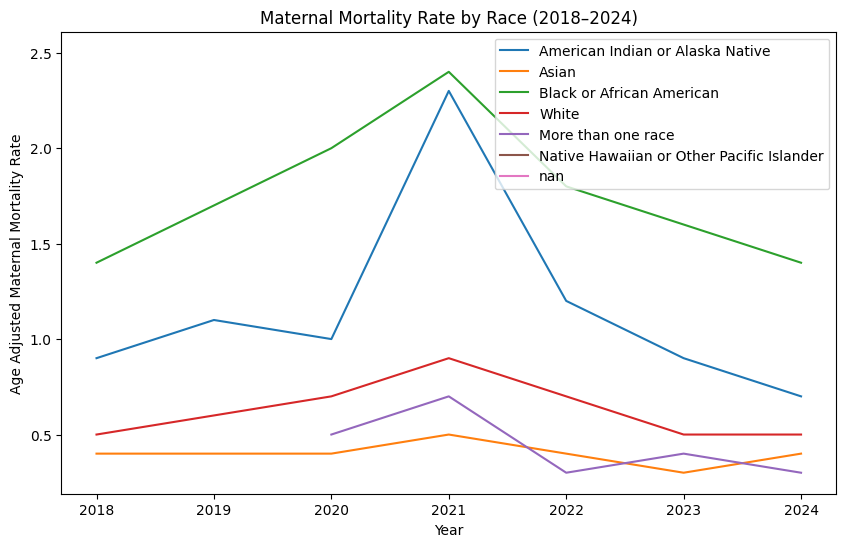

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for race in df['Single Race 6'].unique():
    subset = df[df['Single Race 6'] == race]
    plt.plot(subset['Year'], subset['Age Adjusted Rate'], label=race)

plt.legend()
plt.xlabel("Year")
plt.ylabel("Age Adjusted Maternal Mortality Rate")
plt.title("Maternal Mortality Rate by Race (2018–2024)")
plt.show()

In [8]:
black = df[df['Single Race 6'] == 'Black or African American']
white = df[df['Single Race 6'] == 'White']

gap = black[['Year', 'Age Adjusted Rate']].merge(
    white[['Year', 'Age Adjusted Rate']],
    on='Year',
    suffixes=('_Black', '_White')
)

gap['Black_White_Gap'] = gap['Age Adjusted Rate_Black'] - gap['Age Adjusted Rate_White']
gap

,Year,Age Adjusted Rate_Black,Age Adjusted Rate_White,Black_White_Gap
0,2018.0,1.4,0.5,0.9
1,2019.0,1.7,0.6,1.1
2,2020.0,2.0,0.7,1.3
3,2021.0,2.4,0.9,1.5
4,2022.0,1.8,0.7,1.1
5,2023.0,1.6,0.5,1.1
6,2024.0,1.4,0.5,0.9
